In [1]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os

warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
fires = pd.read_parquet("s3://maap-ops-workspace/shared/zbecker/TESS_fire_spread/sigdeltas_Tess.parq")
subset_fires = gpd.read_parquet("s3://maap-ops-workspace/shared/zbecker/YANG/large_feds_faf_double_matched.parq")
subset_fires = subset_fires.to_crs(4326)

subset_fires["centroid"] = subset_fires.to_crs(4326).centroid
fires["UfireID"] = fires.mergeid.astype("int").astype("str") + "_" + fires.year.astype("str")
subset_fires["UfireID"] = subset_fires.mergeid.astype("str") + "_" + subset_fires.year.astype("str")
subset_fires["polygon"] = subset_fires.geometry
fires = fires[fires.UfireID.isin(subset_fires[subset_fires.intersectsMTBS == True].UfireID)]
fname = pd.read_csv("s3://maap-ops-workspace/shared/zbecker/Eli_MTBS_vs_FEDS/v6_output.csv")

fires = fires.merge(subset_fires[['UfireID', 'centroid', 'polygon']], on = 'UfireID' )
fires = gpd.GeoDataFrame(fires, geometry = 'polygon')

def get_st_sp_fire(df, days_after = 7):
    df.loc[:, "start_time"] = df.t.min()
    df.loc[:, "end_time"] = df.t.max()
    df.loc[:, "end_time_plus"] = df.t.astype("datetime64[ns]").max()  + datetime.timedelta(days = days_after)
    df = df.loc[df.t == df.t.max(), :]
    return(df)
    
fires_sm = fires.groupby("UfireID").apply(get_st_sp_fire).reset_index(drop = True)
fires_sm["stable_index"] = fires_sm.index

In [10]:
precip = pd.read_parquet(os.path.abspath("IMERG/half_hourly_IMERG_precip"))

In [11]:
precip = precip.merge(fires_sm[["UfireID",	"centroid"]], on = "UfireID")

precip.loc[:, "lon"] = precip.centroid.apply(lambda p: p.x)

In [12]:
precip.loc[:, "offset_hour"] = (precip.lon/15)

precip.loc[:, "time_lst"] = precip.time_utc.astype("datetime64[ns]") + pd.to_timedelta(precip["offset_hour"], unit='h') #lst_to_utc_offset_hours =  lon/ 15.0

pm_mask = (precip.time_lst.dt.hour > 6) & (precip.time_lst.dt.hour <= 18) ## correcting to PM 13:30 overpass
am_mask = (precip.time_lst.dt.hour <= 6) | ((precip.time_lst.dt.hour >= 18))## correcting to AM 1:30 overpass. This is actually an exact  number not a range bc we calcuated it for the extraction. 

precip.loc[pm_mask, "t"] = precip.loc[pm_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=12)
precip.loc[am_mask, "t"] = precip.loc[am_mask, "time_lst"].dt.normalize() + pd.Timedelta(hours=0)





In [13]:
## Finding days_since_t
fires.t = fires.t.astype('datetime64[ns]')
fires = fires.merge(precip[[ 'precipitation', 'UfireID', 't']], how = 'outer', on = ['UfireID', 't'])

fires = fires.merge(fires_sm[['UfireID', 'start_time', 'end_time','end_time_plus']], on = 'UfireID')

# foo = fires[fires.UfireID == "10000_2019"]
# foo = foo.sort_values(by = "t")
# foo




## Extraction included the precip values from BEFORE the fire's first growth increment

In [29]:
## Calculating time offset from ending
fires['end_time_offset'] =  fires.t.astype("datetime64[ns]") - fires.end_time.astype("datetime64[ns]") # Positive means days past the end date
fires['start_time_offset'] = fires.t.astype("datetime64[ns]") - fires.start_time.astype("datetime64[ns]") # Positive means days past the start date, negative means before
fires['start_off_12hrs'] = fires['start_time_offset'] / pd.Timedelta(hours=12) = fires['start_time_offset'] / pd.Timedelta(hours=12)
fires['end_off_12hrs'] = fires['end_time_offset'] / pd.Timedelta(hours=12)

### calculating timeoffset from begining

# Plots!

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

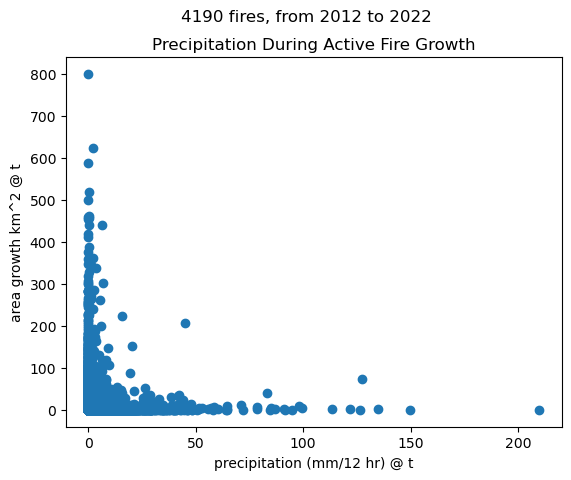

In [49]:

af_mask =  (fires['start_off_12hrs'] >= 0) & (fires['end_off_12hrs'] <= 0)

plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation During Active Fire Growth")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

# Zeb's dataset doesn't have the non-spread timesteps, so we don't have the times when firegrowth = 0 in the above plot

In [50]:
fires.loc[af_mask & (fires.area_growth_at_t_km2.isna()), "area_growth_at_t_km2"] = 0

Text(0.5, 0.98, '4190 fires, from 2012 to 2022')

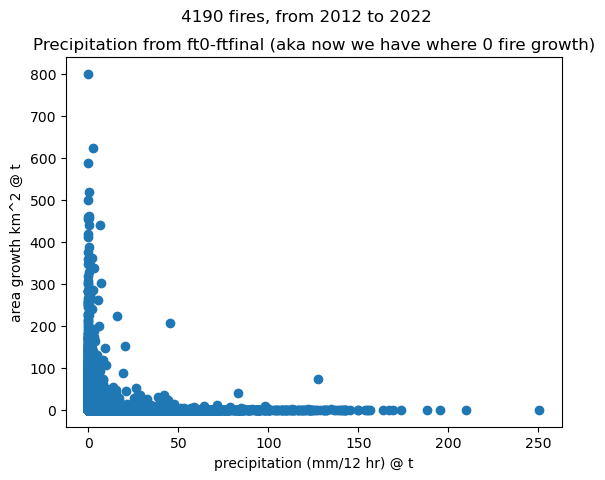

In [52]:
plt.scatter(y = fires[af_mask].area_growth_at_t_km2, x = fires[af_mask].precipitation)
plt.xlabel("precipitation (mm/12 hr) @ t")
plt.ylabel("area growth km^2 @ t")
plt.title("Precipitation from ft0-ftfinal (aka now we have where 0 fire growth)")
plt.suptitle(f"{fires[af_mask].UfireID.nunique()} fires, from {fires[af_mask].t.dt.year.min()} to {fires[af_mask].t.dt.year.max()}")

#### How many fires ended after precipitation? 

I will look at the distribution of precip 
 - after fires ended (12 hour increment to start out)
 - during fires
 - before fires started (12 hour increment)
 - if ending precip bigger than during precip important? (dunno)





In [ ]:
fires